In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

import torch
import numpy as np
import random
import os
import cv2

# Set seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

# CUDA deterministic settings
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [5]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import ClipTypes, OdometerTicks, OdometerTickRange, ViewDistance
from ilipy.sensors import ArmAngleLookup

from tqdm import tqdm
from typing import Dict

from rnd.utils.modeling import get_model

In [6]:
run_number = 4
root_dir = f"./data/fhr{run_number}/val2"
os.makedirs(root_dir, exist_ok=True)
inspection_id = '09JBC62FLJZ'
env = 'research'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
session = Session(environment=env)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.17.5.11628 cbc18e3397 release-ili-0.17 'Tue Sep 16 22:43:55 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(153): WebSoc

In [8]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [9]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

In [10]:
model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_final_40.pth")

In [11]:
def resize_to_224(x: np.ndarray) -> np.ndarray:
    return np.stack([cv2.resize(xi, (224, 224), interpolation=cv2.INTER_NEAREST) for xi in x], axis=0)
transform = transforms.Compose(
    [
        transforms.Lambda(resize_to_224), # should output (C, H, W)
        transforms.Lambda(lambda x: torch.from_numpy(x).float()),
        transforms.Normalize(
            mean=weights.transforms().mean, std=weights.transforms().std
        ),
    ]
)

In [12]:
def create_arm_array(
    arm_data_dict: Dict[str, pd.DataFrame],
    num_tracks: int = 20,
    num_tick_samples: int = 500,
    normalize: str = "patch",
) -> np.ndarray:
    all_dfs = pd.concat(arm_data_dict.values(), ignore_index=True)
    grouped = all_dfs.groupby("track_index")["arm_axis_angles_rad"]
    groups = {track_idx: group.values for track_idx, group in grouped}

    arm_array = np.zeros((num_tracks, num_tick_samples), dtype=np.float32)

    for i in range(num_tracks):
        if i in groups:
            values = groups[i]
            length = min(num_tick_samples, len(values))
            arm_array[i, :length] = values[:length]
            if length < num_tick_samples and length > 0:
                arm_array[i, length:] = values[length - 1]

    if normalize == "std":
        arm_array = arm_array - arm_array.mean(axis=1, keepdims=True)
        max_std_index = np.argmax(np.std(arm_array, axis=1, keepdims=True))

        row_min = arm_array.min(axis=1, keepdims=True)[max_std_index]
        row_max = arm_array.max(axis=1, keepdims=True)[max_std_index]
        denom = np.where((row_max - row_min) == 0, 1, row_max - row_min)
        arm_array = (arm_array - row_min) / denom
           
        return arm_array
    elif normalize == "patch":

        row_min = arm_array.min(axis=1, keepdims=True)
        row_max = arm_array.max(axis=1, keepdims=True)
        denom = np.where((row_max - row_min) == 0, 1, row_max - row_min)
        arm_array = (arm_array - row_min) / denom
        return arm_array
    else: #not normalize
        return arm_array
        
def extract_arm_angles(
    session, dist_corr, view_distance_range_m, tick_sampling_interval=10
):
    """
    Processes inspection data by sampling odometer ticks within a specified view distance range
    and extracting relevant metrics for each clip.
    Args:
        env (Environment): The environment object representing the current simulation or system state.
        inspection_id (str): The unique identifier for the inspection session.
        view_distance_range_m (tuple): A tuple (start_vd, end_vd) specifying the range of view distances
            in meters to process.
        tick_sampling_interval (int, optional): The interval (in ticks) at which to sample odometer ticks
            within the overlapping range. Defaults to 10.
    Returns:
        dict: A dictionary where each key is a clip ID, and the value is a pandas DataFrame containing
            sampled data. Each DataFrame includes the following columns:
            - "track_index": The index of the track associated with the clip.
            - "odometer_tick": The sampled odometer tick.
            - "view_distances_m": The view distance in meters at the sampled tick.
            - "arm_axis_angles_rad": The arm axis angle in radians at the sampled tick.
    Notes:
        - Clips are filtered based on their overlap with the specified view distance range.
        - Sampling is performed only within the overlapping tick range for each clip.
        - Clips that cannot map the specified view distances or do not yield any samples are skipped.

    """
    all_arms = {}
    clips = session.get_clips_by_type(ClipTypes.ChannelData)

    start_vd, end_vd = view_distance_range_m

    for clip in clips:
        # 1) map view-distances -> odometer-ticks for this clip
        try:
            tick_start = dist_corr.get_odometer_ticks_from_view_distance(
                clip, ViewDistance(start_vd)
            )
            tick_end = dist_corr.get_odometer_ticks_from_view_distance(
                clip, ViewDistance(end_vd)
            )
        except Exception:
            continue  # clip can’t map those distances

        query_range = OdometerTickRange(tick_start, tick_end)
        clip_range = clip.odometer_tick_range

        # 2) skip clips with no raw-tick overlap
        if (
            clip_range.max.value < query_range.min.value
            or clip_range.min.value > query_range.max.value
        ):
            continue

        # 3) clamp to the actual overlapping integer ticks
        lo = max(clip_range.min.value, tick_start.value)
        hi = min(clip_range.max.value, tick_end.value)
        if hi <= lo:
            continue

        # 4) sample every tick_sampling_interval ticks
        arm_lookup = ArmAngleLookup(session, clip)
        rows = []
        for tick in range(int(lo), int(hi) + 1, tick_sampling_interval):
            odot = OdometerTicks(tick)
            angle = arm_lookup.get_axis_angle_from_odometer_ticks(odot)
            # vd_m = dist_corr.get_view_distance_from_odometer_ticks(clip, odot).value
            rows.append(
                {
                    "track_index": clip.track_index,
                    # "odometer_tick": tick,
                    # "view_distances_m": vd_m,
                    "arm_axis_angles_rad": angle,
                }
            )

        # 5) only keep clips where we actually got samples
        if rows:
            all_arms[clip.clip_id] = pd.DataFrame(rows)

    return all_arms

def generate_images(
    session,
    bookmark_locations,
    dist_corr,
    length: float = 0.5,
    num_tracks: int = 20,
    tick_sampling_interval=10,
    normalize: str = "patch",
    output_dir: str = "arm_angles",
):
    """
    Extracts and saves individual arm angle matrices from positive bookmark view distances.

    Args:
        env: The simulation environment.
        inspection_id (str): Inspection session ID.
        bookmark_type (int): Type of bookmark (0 = anchored girth welds).
        range_half_width (float): Half-width of the range around each view distance.
        num_tracks (int): Number of tracks per matrix.
        fixed_length (int): Fixed length of each arm angle row.
        output_dir (str): Directory where .npy files will be saved.
        normalize (str): Normalization method to apply ("patch", "range", or None).

    Returns:
        List[str]: File paths of saved matrices.
    """
    try:
        os.makedirs(output_dir, exist_ok=True)
    except Exception as e:
        raise RuntimeError(f"Failed to create output directory '{output_dir}': {e}")

    if not bookmark_locations:
        raise ValueError("No valid bookmarks found.")

    saved_files = []

    for view_dist in tqdm(bookmark_locations):
        # for view_dist in bookmark_locations:
        try:
            arm_data = extract_arm_angles(
                session=session,
                dist_corr=dist_corr,
                view_distance_range_m=(
                    view_dist - length / 2,
                    view_dist + length / 2,
                ),
                tick_sampling_interval=tick_sampling_interval,
            )
            if not arm_data:
                print(f"No arm data found at view distance {view_dist:.3f} m")
                continue

            num_tick_samples = int(length * 10000 / tick_sampling_interval)
            matrix = create_arm_array(
                arm_data,
                num_tracks=num_tracks,
                num_tick_samples=num_tick_samples,
                normalize=normalize,
            )

            # Save with view distance in filename (rounded to 2 decimals)
            view_dist_mm = round(view_dist * 1000, 2)
            filename = f"d{view_dist_mm:010.0f}.npy"
            filepath = os.path.join(output_dir, filename)
            np.save(filepath, matrix)
            saved_files.append(filepath)
            qc_output_dir = os.path.join(output_dir, "qc")
            os.makedirs(qc_output_dir, exist_ok=True)
            plt.imshow(
                matrix.T, cmap="inferno", origin="lower", aspect="auto",
                interpolation="nearest",vmin=0, vmax=1
            )
            plt.colorbar()
            plt.axis("off")
            plt.savefig(
                os.path.join(qc_output_dir, f"{view_dist_mm:010.0f}.png"),
                bbox_inches="tight",
                pad_inches=0,
            )
            plt.close()

        except Exception as e:
            print(f"Skipping view distance {view_dist:.2f} due to error: {e}")
            continue

    print(f"Saved {len(saved_files)} arm angle matrices to '{output_dir}'")
    return saved_files

In [13]:
def gen_image(img_start, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=20,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img

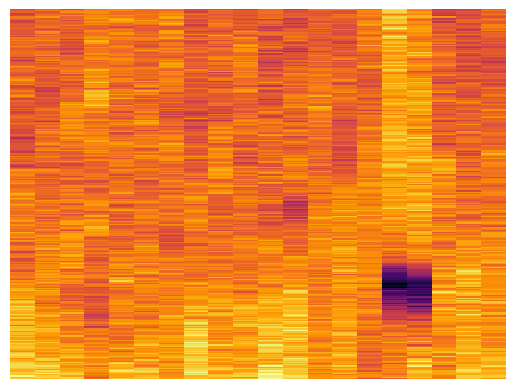

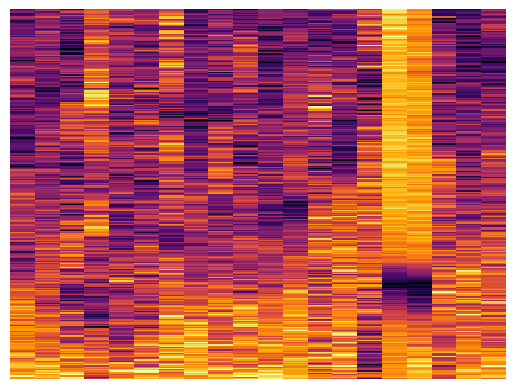

Image start: 115892.17, Predicted class: [0], Probability: [0.99999917]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


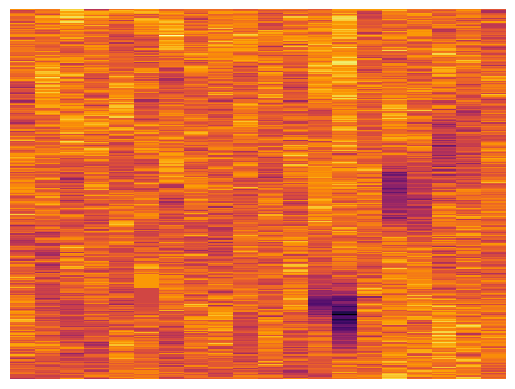

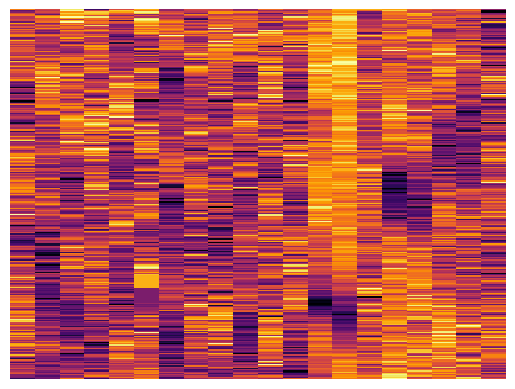

Image start: 116673.42, Predicted class: [0], Probability: [0.99999344]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


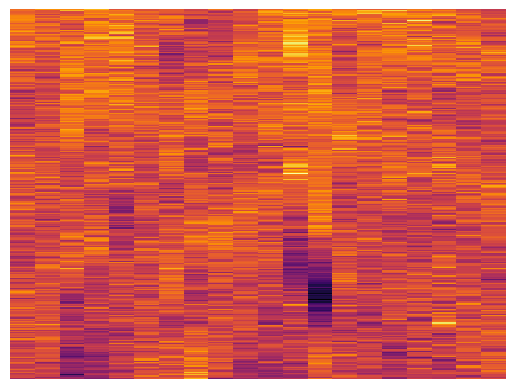

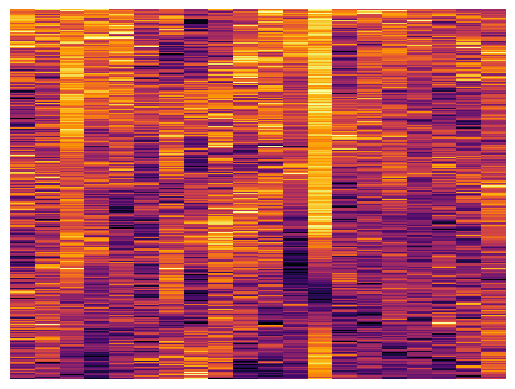

Image start: 119393.23, Predicted class: [0], Probability: [0.99999654]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


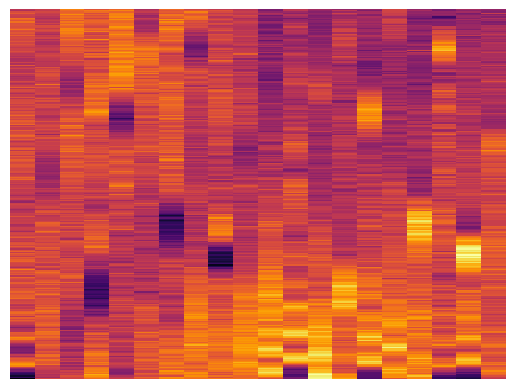

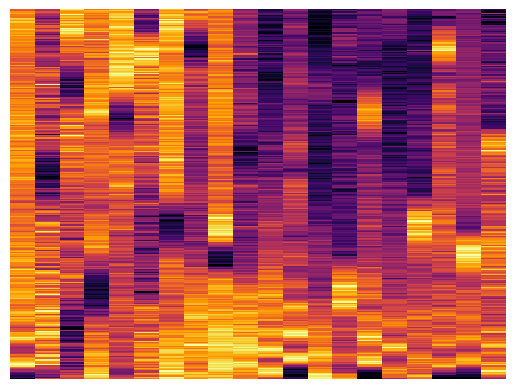

Image start: 121230.787, Predicted class: [0], Probability: [0.9999982]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


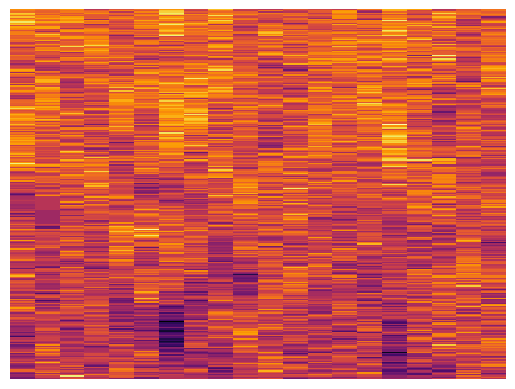

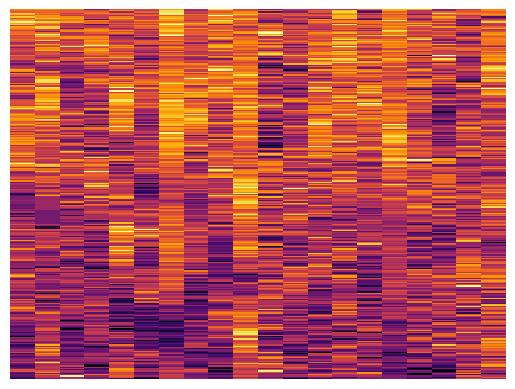

Image start: 125938.23, Predicted class: [0], Probability: [0.9999957]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


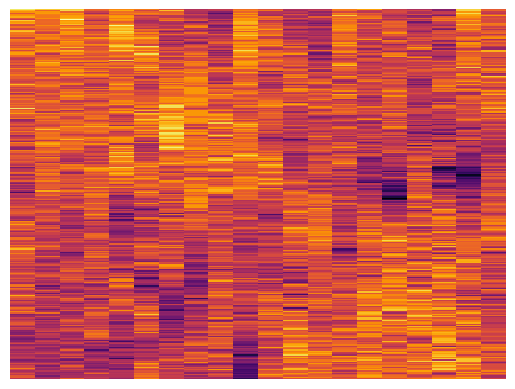

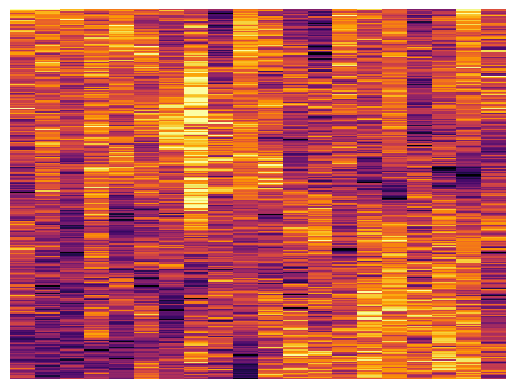

Image start: 133662.61, Predicted class: [0], Probability: [0.9999989]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


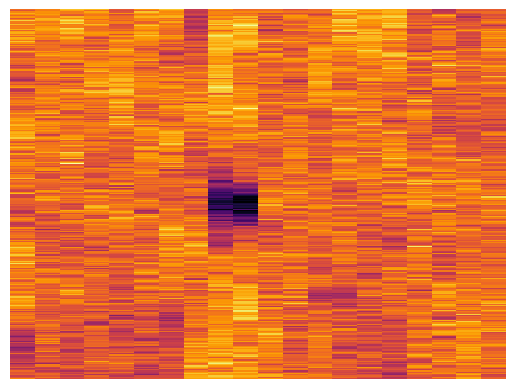

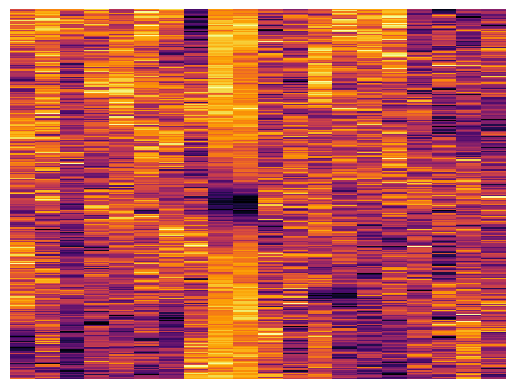

Image start: 143069.72, Predicted class: [0], Probability: [0.9999994]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


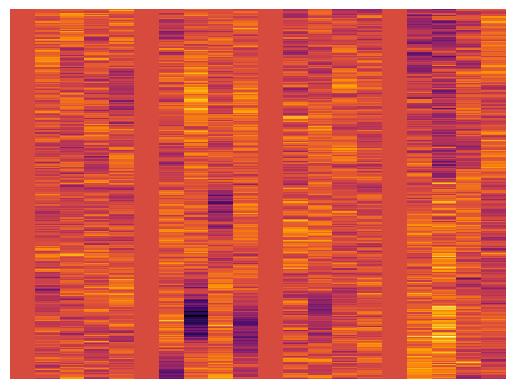

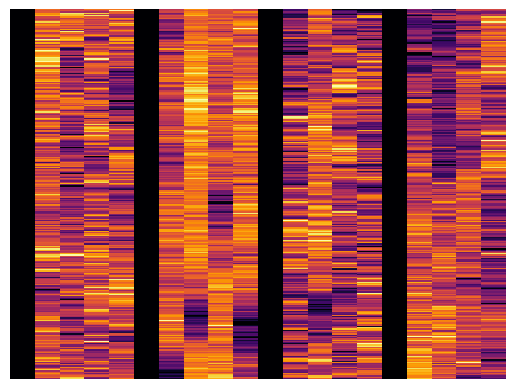

Image start: 165940.68, Predicted class: [0], Probability: [0.99999726]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


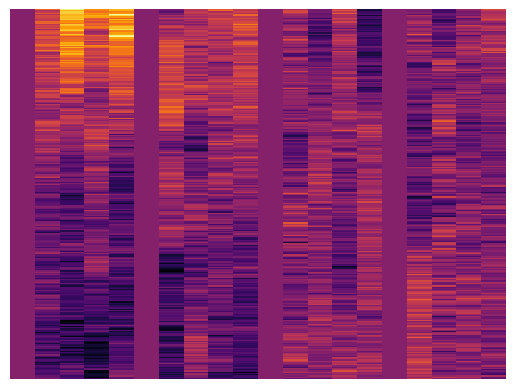

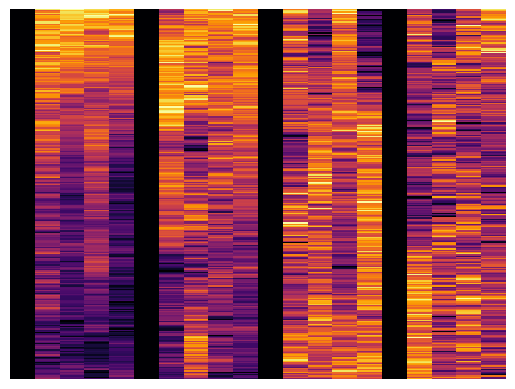

Image start: 168731.22, Predicted class: [0], Probability: [0.9999808]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


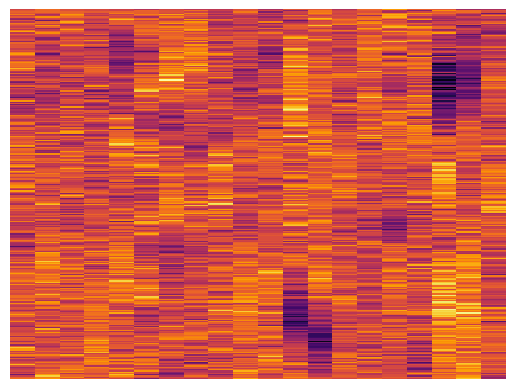

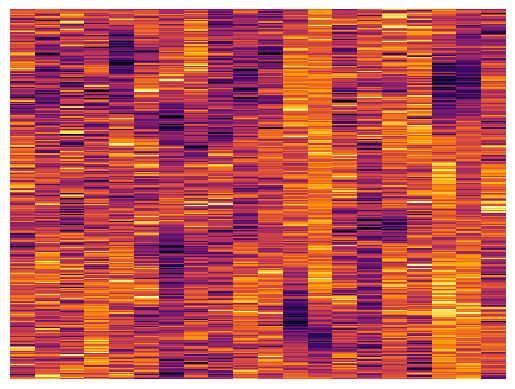

Image start: 140987.67, Predicted class: [0], Probability: [0.9999902]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


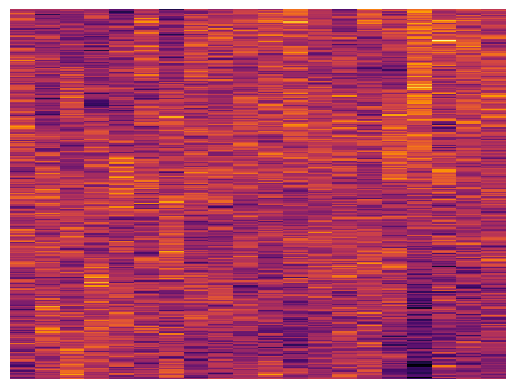

DbHealthCheck.cpp(146): Database service health check complete: Healthy


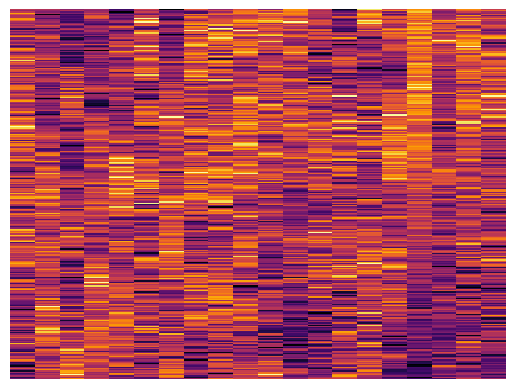

Image start: 139915.71, Predicted class: [0], Probability: [0.9999982]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


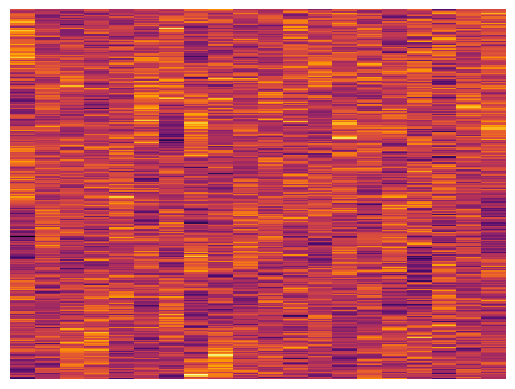

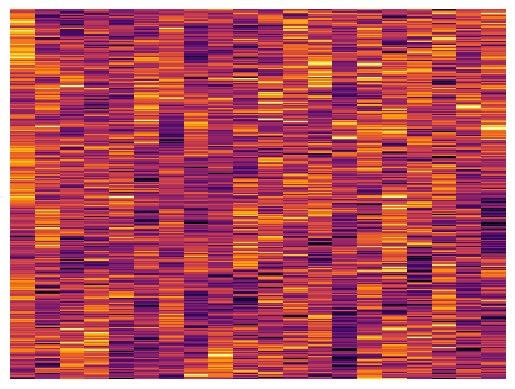

Image start: 131142.14, Predicted class: [0], Probability: [0.99999475]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


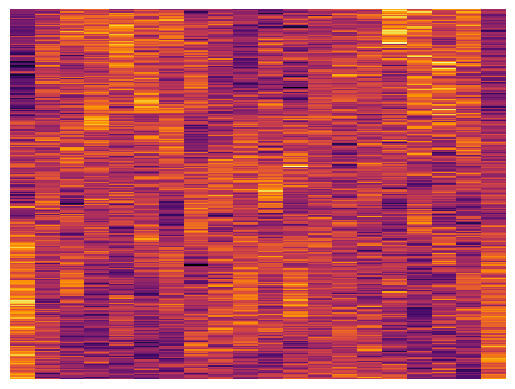

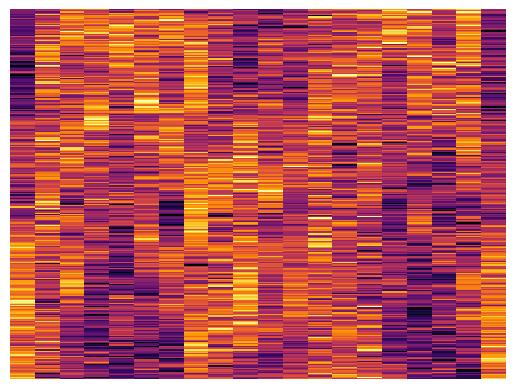

Image start: 130736.36, Predicted class: [0], Probability: [0.9999945]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


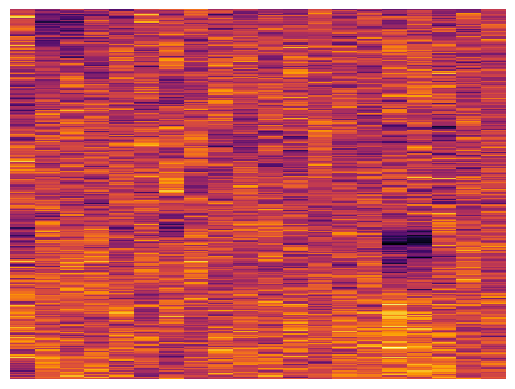

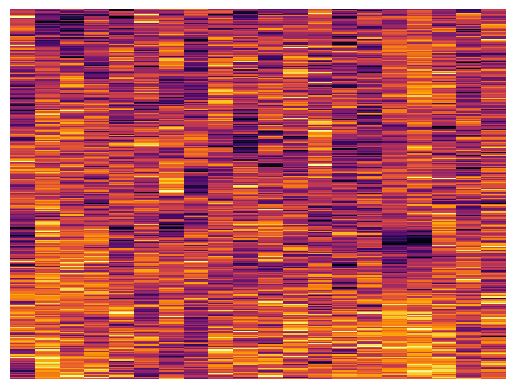

Image start: 130167.86, Predicted class: [0], Probability: [0.9999938]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


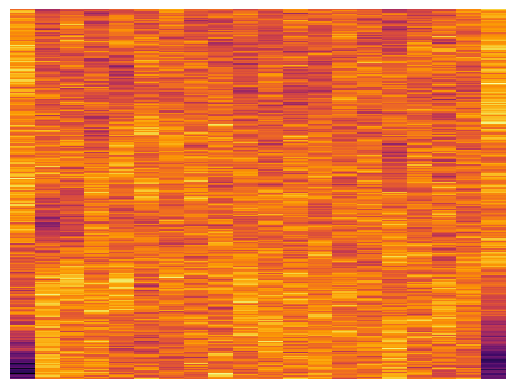

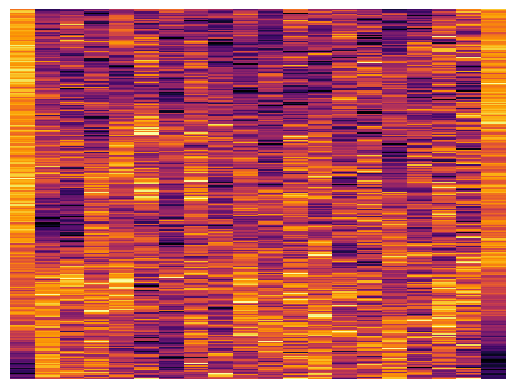

Image start: 129523.31, Predicted class: [0], Probability: [0.9999964]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


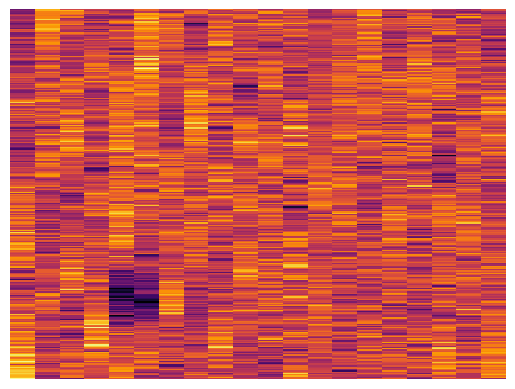

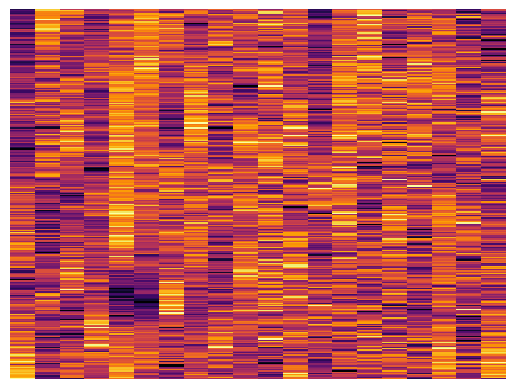

Image start: 128453.82, Predicted class: [0], Probability: [0.9999938]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


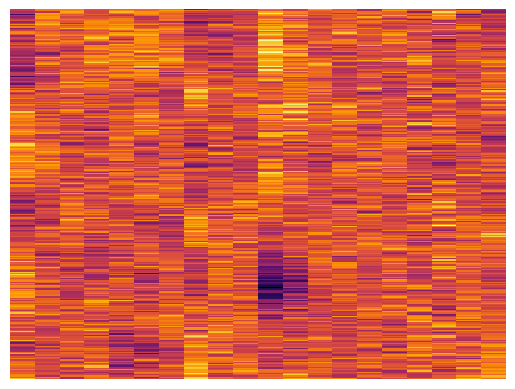

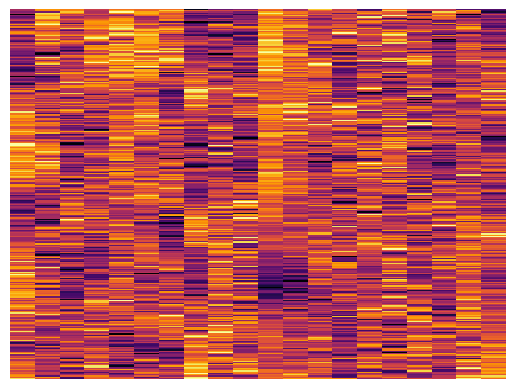

Image start: 127133.68, Predicted class: [0], Probability: [0.99999547]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


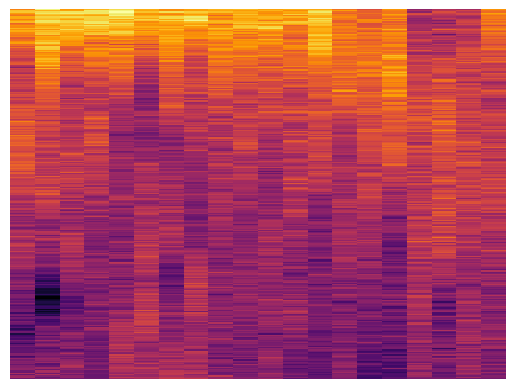

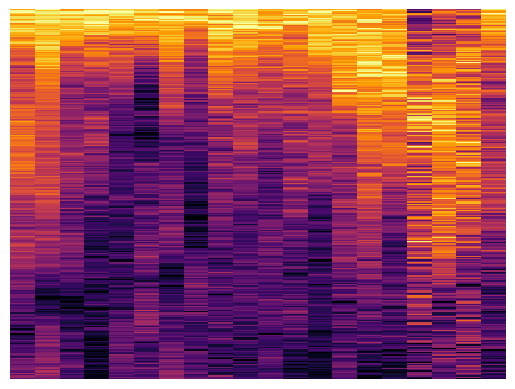

Image start: 124551.54, Predicted class: [0], Probability: [0.99999666]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


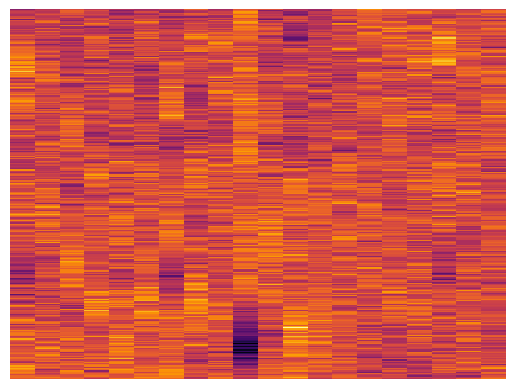

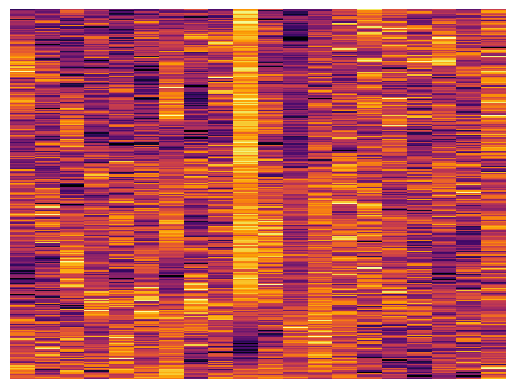

Image start: 119253.33, Predicted class: [0], Probability: [0.99999905]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


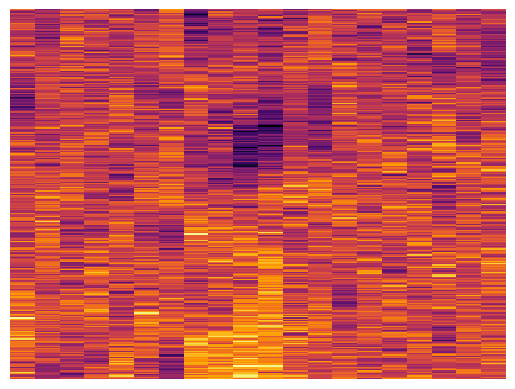

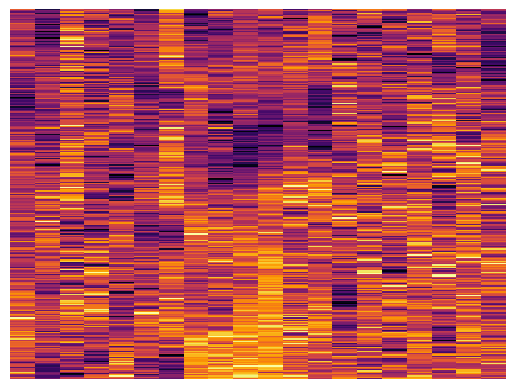

Image start: 119142.37, Predicted class: [0], Probability: [0.99998677]
tensor([[ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False]])


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [ ]:
fhr4_dent_validation_locations = [115892.170, 116673.420, 119393.230, 121230.787, 125938.230, 133662.610, 143069.720, 
165940.680, 168731.220, 140987.670, 139915.710, 131142.140, 130736.360, 130167.860, 129523.310, 128453.820, 127133.680,
124551.540, 119253.330, 119142.370]
model.eval()  # Ensure model is on CPU for inference
patch_length = 0.3  # Length of the patch in meters
with torch.no_grad():
    for img_start in fhr4_dent_validation_locations:
        img_std = gen_image(img_start, show_im=True, normalize="std")
        img_patch = gen_image(img_start, show_im=True, normalize="patch")
        img_patch_trend = seasonal_decompose(img_patch.T, model='additive', period=30, extrapolate_trend=2).trend.T
        img = np.stack((img_patch, img_patch_trend, img_std), axis=0)  # shape: (3, H, W)
        img = transform(img)
        raw_outputs = model(img.unsqueeze(0))  # Add batch dimension and move to device
        preds = raw_outputs.argmax(dim=1).cpu().numpy()
        probs = raw_outputs.sigmoid().max(dim=1).values.cpu().numpy()
        print(f"Image start: {img_start}, Predicted class: {preds}, Probability: {probs}")
        print((raw_outputs.sigmoid() > 0.9))
